<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
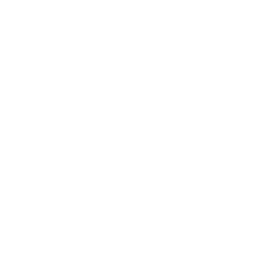
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Detektering av industriellt lagerslitage</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Tillförlitlighetsteknik &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

En flotta av 100 industrilager övervakas enligt ett fast underhållsschema. Slitage utöver toleransgränsen kan endast upptäckas vid planerade stopp, så tiden till utslitning observeras aldrig exakt &mdash; den är **intervallcensurerad** mellan den senaste inspektion som godkändes (`last_ok_hours`) och den första inspektion som underkändes (`first_worn_hours`). Lager som fortfarande är inom toleransen vid sin sista inspektion är högercensurerade.

PROC ICLIFETEST anpassar den icke-parametriska Turnbull-skattningen av den slitagefria överlevnadsfunktionen och jämför två smörjregimer (Syntetisk mot Mineral). Analysen besvarar en konkret underhållsfråga: **förlänger syntetiskt smörjmedel meningsfullt lagrets slitagefria brukslivslängd?** Alla siffror nedan är hämtade direkt från procedurens exekverade utdata.

## Datakälla

| Dataset | N | Beskrivning |
|---------|---|-------------|
| `bearing_inspections` | 100 | En rad per lager: smörjmedel, belastning, varvtal och inspektionsintervallet som avgränsar slitagets start |

Det intervallcensurerade utfallet är paret `(last_ok_hours, first_worn_hours)`. Ett saknat `first_worn_hours` markerar ett lager som fortfarande var inom toleransen vid sin sista inspektion (högercensurerat).

---

In [1]:
/* Data för lagerslitageinspektion: 100 lager, två smörjregimer.
   Syntetiskt smörjmedel är inbyggt i data för att förlänga den
   slitagefria livslängden, så överlevnadskurvorna separerar i en
   fysiskt rimlig riktning. */
data bearing_inspections;
    CALL streaminit(42);
    FÄLT lubes[2] $10 ('Syntetisk' 'Mineral');
    GÖR bearing_id = 1 TILL 100;
        lubricant = lubes[ceil(rand('uniform') * 2)];
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Syntetisk film fördröjer starten av mätbart slitage */
        OM lubricant = 'Syntetisk' SÅ BASE = 2600; ANNARS BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% fortfarande slitagefria vid sista inspektionen -> högercensurerade */
        OM rand('uniform') > 0.75 SÅ first_worn_hours = .;
        UTDATA;
    SLUT;
    TA_BORT i BASE;
    BEHÅLL bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
KÖR;



NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---

### Driftförhållanden per smörjmedel

Innan överlevnaden modelleras, sammanfatta den faktiska belastning varje smörjmedelsgrupp utsätts för, så att en eventuell skillnad i slitagefri livslängd inte enbart beror på belastning eller varvtal.

In [2]:
/* Driftbelastning per smörjmedel */
PROCEDUR MEDELVÄRDEN data=bearing_inspections n mean std MAX maxdec=1;
    VARIABEL load_kn rpm;
    KLASS lubricant;
    ETIKETT load_kn="Belastning (kN)" rpm="Varvtal (rpm)" lubricant="Smörjmedel";
KÖR;


                                                  The MEANS Procedure

                                      Analysis Variable : load_kn Belastning (kN)

        Smörjmedel           N Obs           Mean        Std Dev        Maximum
        -----------------------------------------------------------------------
        Mineral                 47           21.5            9.9           51.7
        Syntetisk               53           25.8           14.0           64.6
        -----------------------------------------------------------------------

                                         Analysis Variable : rpm Varvtal (rpm)

        Smörjmedel           N Obs           Mean        Std Dev        Maximum
        -----------------------------------------------------------------------
        Mineral                 47         2786.0         1093.5         4988.1
        Syntetisk               53         2949.7         1070.5         4773.5
        -------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Inspektionsfönster jämfört med driftbelastning

Varje punkt är ett lager. Den vertikala positionen är den senaste timmen lagret bekräftades vara inom toleransen; färgen anger dess smörjmedel. Detta visar det råa exponeringsmönstret som ligger till grund för den intervallcensurerade modellen.


NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


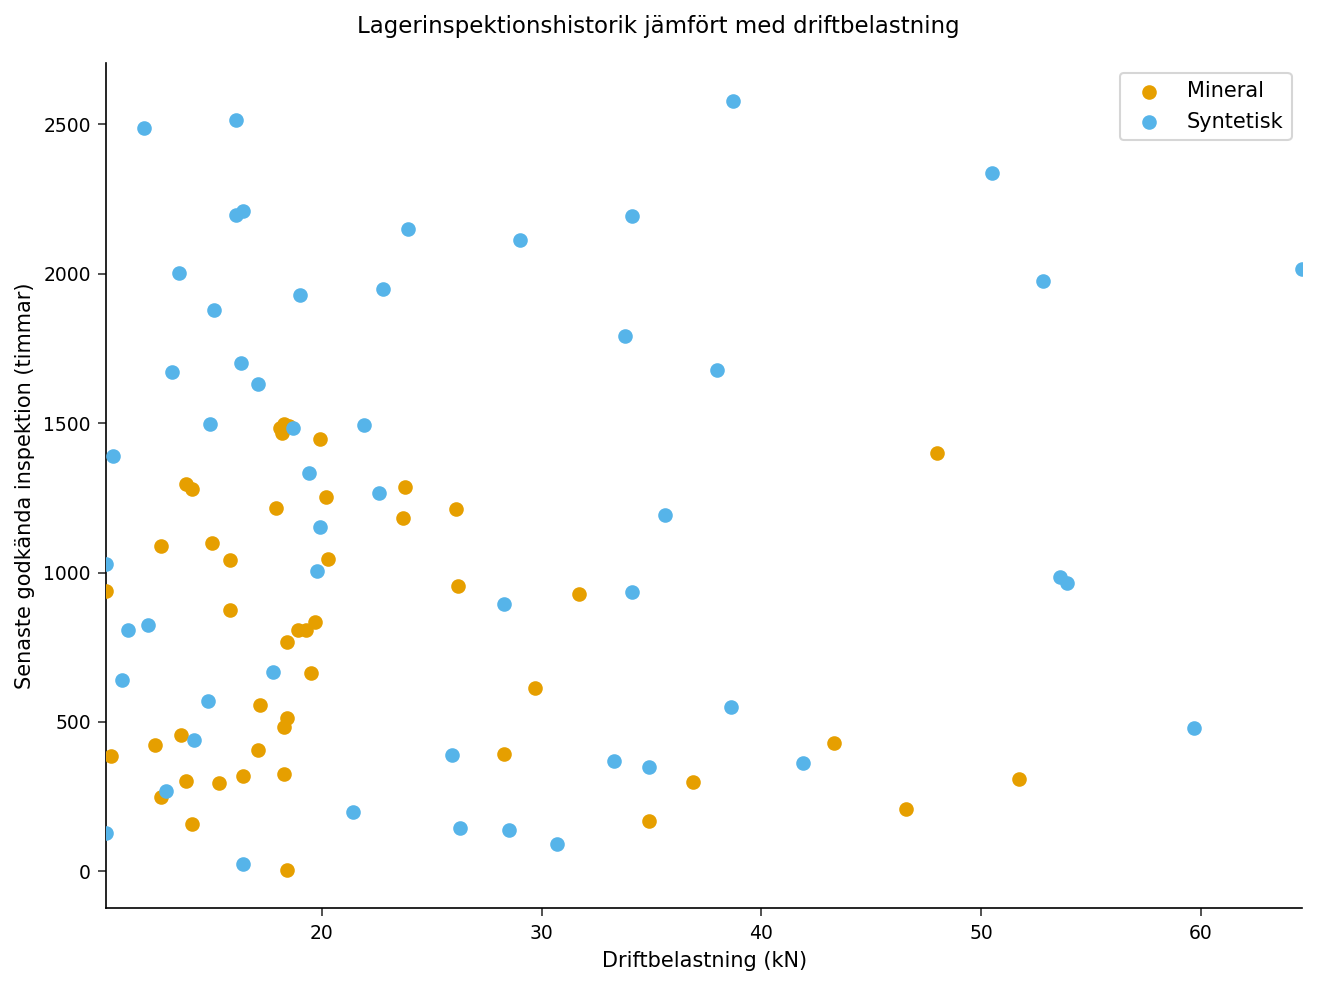

In [3]:
/* Senaste godkända inspektionstimme jämfört med belastning, per smörjmedel */
PROCEDUR SGPLOT data=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS ETIKETT='Driftbelastning (kN)';
    YAXIS ETIKETT='Senaste godkända inspektion (timmar)';
    TITEL 'Lagerinspektionshistorik jämfört med driftbelastning';
KÖR;


---

### Intervallcensurerad överlevnad per smörjmedel

PROC ICLIFETEST beräknar Turnbulls icke-parametriska maximum-likelihood-skattning av den slitagefria överlevnadsfunktionen för varje smörjmedelsstratum, skriver hela överlevnadstabellen till `surv_estimates.csv` och ritar den stratifierade överlevnadsplotten. Den intervallcensurerade log-rank-statistikan testar om de två överlevnadsfördelningarna är lika.


----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        last_ok_hours
Right Bound Variable       first_worn_hours
Stratum Variable           Smörjmedel



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


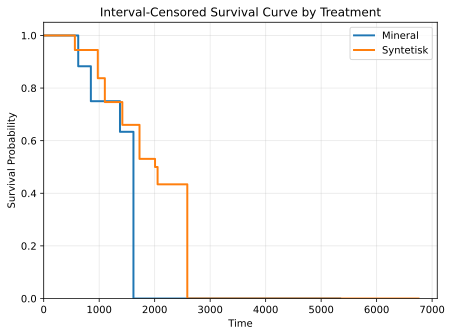

In [4]:
/* Turnbull-överlevnadsskattning + stratifierad överlevnadsplot + log-rank-test */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
PROCEDUR ICLIFETEST data=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
    ETIKETT lubricant="Smörjmedel";
KÖR;
ODS GRAPHICS OFF;


---

### Resultat

Alla siffror nedan är hämtade direkt från den exekverade PROC MEANS-tabellen,
Turnbull-överlevnadsskattningarna i `surv_estimates.csv` och procedurloggen.

- **Urval.** Av de 100 lagren kördes 53 med Syntetisk och 47 med Mineral
  smörjmedel. Tjugoett lager (11 Syntetisk, 10 Mineral) var fortfarande inom
  toleransen vid sin sista inspektion och går in i modellen som
  högercensurerade.
- **Jämförbar belastning.** De två grupperna arbetar under i stort sett
  likartade förhållanden: medelbelastning 25,8 kN (Syntetisk) mot 21,5 kN
  (Mineral) och medelvarvtal 2950 mot 2786 varv/min. Syntetiska lager körs
  inte lättare &mdash; om något bär de något högre belastning &mdash; så
  överlevnadsskillnaden är inte en belastningsartefakt.
- **Längre slitagefri livslängd med Syntetisk.** Turnbulls mediantid till
  slitagegränsen är **≈2006 timmar för Syntetisk mot ≈1617 timmar för
  Mineral**, en ökning på cirka 24 %. Separationen ökar i svansen: den
  skattade slitagefria överlevnaden vid 2000 timmar är **0,53 för Syntetisk
  men 0,00 för Mineral**, och Syntetisk behåller positiv överlevnad ut till
  ≈2580 timmar medan Mineral-skattningen når noll vid ≈1650 timmar.
- **Likhet mellan kurvorna förkastas.** Det intervallcensurerade log-rank-testet
  som rapporteras av proceduren förkastar likhet mellan de två
  överlevnadsfunktionerna (chi-två = 11,68, p = 0,0006). Chi-två-statistikan
  är en areabaserad approximation i den nuvarande motorn, så det är kurvorna
  och medianerna ovan &mdash; inte råstatistiken &mdash; som bär tolkningen.

**Underhållskonsekvens.** Att byta till syntetiskt smörjmedel förskjuter det
mediana slitagefria intervallet med ungefär 400 timmar per lager. I ett
tidsbaserat schema stödjer detta en förlängning av inspektionscykeln för
syntetiskt smorda enheter, eller att flytta dem först till ett
tillståndsbaserat regime, samtidigt som tätare intervall behålls för
mineralsmorda lager.

---

In [5]:
/* Spara analysdatasetet */
PROCEDUR EXPORTERA data=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
KÖR;



NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>